<a href="https://colab.research.google.com/github/ayushi777lodhi-stack/Vision-MultiModal-Learning/blob/main/vit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision
import torch.utils.data as dataloader

In [2]:
transformation_operation=torchvision.transforms.Compose([torchvision.transforms.ToTensor()])

In [3]:
train_dataset=torchvision.datasets.MNIST(root='./data', train=True, download= True,transform=transformation_operation)
val_dataset=torchvision.datasets.MNIST(root='./data', train=False, download= True,transform=transformation_operation)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.0MB/s]


In [4]:
img, label = train_dataset[0]
print(type(img))

<class 'torch.Tensor'>


In [5]:
num_classes=10
batch_size=64
num_channels=1
patch_size=7
img_size=28
num_patches=(img_size//patch_size)**2
embedding_dim=64
attention_heads=4
transformer_blocks=4
learning_rate=0.001
mlp_hidden_nodes=128
epochs=5

In [6]:
train_loader=dataloader.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader=dataloader.DataLoader(val_dataset, batch_size=64, shuffle=True)

In [7]:
import torch.nn as nn
class PatchEmbedding(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embed=nn.Conv2d(num_channels,embedding_dim,kernel_size=patch_size,stride=patch_size)

  def forward(self,x):
    x=self.patch_embed(x)
    x=x.flatten(2)
    x=x.transpose(1,2)
    return x




In [8]:
class TransformerEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1=nn.LayerNorm(embedding_dim)
    self.layer_norm2=nn.LayerNorm(embedding_dim)
    self.multihead_attention = nn.MultiheadAttention(embedding_dim, attention_heads, batch_first=True)
    self.mlp=nn.Sequential(
        nn.Linear(embedding_dim, mlp_hidden_nodes),
        nn.GELU(),
        nn.Linear(mlp_hidden_nodes,embedding_dim)
    )

  def forward(self,x):
      residual1=x
      x=self.layer_norm1(x)
      x=self.multihead_attention(x,x,x)[0]
      x=x+residual1

      residual2=x
      x=self.layer_norm2(x)
      x=self.mlp(x)
      x=x+residual2

      return x

In [9]:
class MLP_head(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1=nn.LayerNorm(embedding_dim)
    self.mlp_head=nn.Linear(embedding_dim, num_classes)

  def forward(self,x):
    x=self.layer_norm1(x)
    x=self.mlp_head(x)

    return x


In [10]:
class VisionTransformer(nn.Module):
  def __init__(self):
    super().__init__()

    self.patch_embedding=PatchEmbedding()
    self.cls_token=nn.Parameter(torch.randn(1,1,embedding_dim))
    self.position_embedding=nn.Parameter(torch.randn(1,num_patches+1,embedding_dim))
    self.transformer_blocks=nn.Sequential(
        *[TransformerEncoder() for _ in range(transformer_blocks)]
    )
    self.mlp_head=MLP_head()


  def forward(self,x):
    x=self.patch_embedding(x)
    B=x.size(0)
    class_tokens=self.cls_token.expand(B,-1,-1)
    x=torch.cat((class_tokens,x),dim=1)
    x=x+self.position_embedding
    x=self.transformer_blocks(x)
    x=x[:,0]
    x=self.mlp_head(x)

    return x

In [11]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model=VisionTransformer().to(device)
optimizer=torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion=nn.CrossEntropyLoss()

In [12]:
for epoch in range(epochs):
  model.train()
  total_loss=0
  correct_epoch=0
  total_epoch=0

  print(f"\nEpoch {epoch+1}")

  for batch_idx,(images,labels) in enumerate(train_loader):
    images,labels=images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs=model(images)
    loss=criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    total_loss+=loss.item()
    preds=outputs.argmax(dim=1)
    correct=(preds==labels).sum().item()
    accuracy=100.0*correct/labels.size(0)
    correct_epoch+=correct
    total_epoch+=labels.size(0)

    if batch_idx%100==0:
      print(f"batch {batch_idx+1:3d}, loss={loss.item():.4f}, accuracy={accuracy: .2f}%")

  epoch_acc=100.0*correct_epoch/total_epoch
  print(f"epoch:{epoch+1} , total loss={total_loss:.4f}, accuracy={epoch_acc:.2f}%")


Epoch 1
batch   1, loss=2.3223, accuracy= 14.06%
batch 101, loss=0.6196, accuracy= 75.00%
batch 201, loss=0.3306, accuracy= 90.62%
batch 301, loss=0.3376, accuracy= 90.62%
batch 401, loss=0.1974, accuracy= 93.75%
batch 501, loss=0.1443, accuracy= 95.31%
batch 601, loss=0.1858, accuracy= 95.31%
batch 701, loss=0.1068, accuracy= 95.31%
batch 801, loss=0.2102, accuracy= 98.44%
batch 901, loss=0.0953, accuracy= 95.31%
epoch:1 , total loss=345.0839, accuracy=88.47%

Epoch 2
batch   1, loss=0.1097, accuracy= 96.88%
batch 101, loss=0.0838, accuracy= 95.31%
batch 201, loss=0.1449, accuracy= 95.31%
batch 301, loss=0.0979, accuracy= 95.31%
batch 401, loss=0.1196, accuracy= 95.31%
batch 501, loss=0.1201, accuracy= 93.75%
batch 601, loss=0.1539, accuracy= 93.75%
batch 701, loss=0.0737, accuracy= 98.44%
batch 801, loss=0.1009, accuracy= 98.44%
batch 901, loss=0.0688, accuracy= 96.88%
epoch:2 , total loss=113.1822, accuracy=96.25%

Epoch 3
batch   1, loss=0.0206, accuracy= 100.00%
batch 101, loss=0

In [13]:
model.eval()
correct=0
total=0

with torch.no_grad():
  for images, labels in val_loader:
    images,labels=images.to(device), labels.to(device)
    outputs=model(images)
    preds=outputs.argmax(dim=1)
    correct +=(preds==labels).sum().item()
    total+=labels.size(0)

val_acc=100.0*correct/total
print(f"accuracy:{val_acc}")

accuracy:97.49


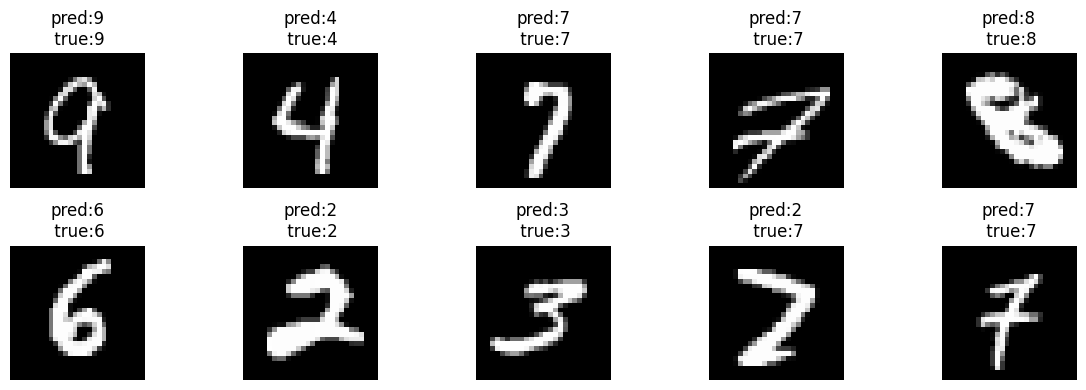

In [15]:
import matplotlib.pyplot as plt
model.eval()

images,labels=next(iter(val_loader))
images,labels=images.to(device),labels.to(device)
with torch.no_grad():
  outputs=model(images)
  preds=outputs.argmax(dim=1)

images=images.cpu()
preds=preds.cpu()
labels=labels.cpu()

plt.figure(figsize=(12,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(images[i].squeeze(),cmap='gray')
  plt.title(f"pred:{preds[i].item()}\n true:{labels[i].item()}")
  plt.axis('off')

plt.tight_layout()
plt.show()